# Problème d'arrêt optimal — Jeu de cartes rouge/noir
## Partie I : Programmation dynamique | Partie II : Asymptotique et pont brownien

**Référence :** Ekström, E. & Wanntorp, H. (2009). *Optimal stopping of a Brownian bridge*. Journal of Applied Probability, 46(1), 170–180.


## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm

# Reproductibilité
np.random.seed(42)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})


## Partie I — Modélisation et programmation dynamique

### Cadre du problème

On tire sans remise depuis un paquet de $2N$ cartes ($N$ rouges $= +1$, $N$ noires $= -1$).

**État** : $(r, b)$ = (rouges restantes, noires restantes).

**Gain total** à l'état $(r, b)$ si arrêt immédiat :
$$G = (N - r) - (N - b) = b - r.$$

**Fonction valeur** :
$$J(r, b) = \sup_{\tau} \, \mathbb{E}\!\left[G_\tau \mid R_0 = r,\, B_0 = b\right].$$

**Équation de Bellman** :
$$J(r, b) = \max\!\left(b - r,\; \frac{r}{r+b}\,J(r-1,b) + \frac{b}{r+b}\,J(r,b-1)\right),$$
avec $J(0, b) = b$ et $J(r, 0) = 0$.


### Algorithme : backward induction

In [2]:
def compute_J(N):
    """
    Calcule la table J(r,b) pour r,b in {0,...,N} par backward induction.
    
    J(r,b) = gain total optimal espere depuis l'etat (r,b).
    
    Conditions aux bords :
      J(0, b) = b  (arreter : gain = b, continuer = -1+J(0,b-1) = b-2 < b)
      J(r, 0) = 0  (continuer toutes les rouges : gain final = 0 > -r)
    """
    J = np.zeros((N+1, N+1))
    # Bord r=0 : arreter immediatement
    for b in range(N+1):
        J[0, b] = b
    # Bord b=0 : continuer jusqu'a epuisement (gain final = 0)
    for r in range(1, N+1):
        J[r, 0] = 0
    # Recursion de Bellman
    for r in range(1, N+1):
        for b in range(1, N+1):
            p = r / (r + b)          # P(prochaine carte = rouge)
            continuation = p * J[r-1, b] + (1-p) * J[r, b-1]
            J[r, b] = max(b - r, continuation)
    return J

# Application N=26
N = 26
J26 = compute_J(N)
print(f"J(26, 26) = {J26[26,26]:.6f} dollars")


J(26, 26) = 2.624476 dollars


### Résultats pour différentes valeurs de $N$

In [3]:
N_list = [1, 2, 5, 10, 20, 26, 50, 100, 200, 500, 1000]
print(f"{'N':>6} | {'J(N,N)':>12} | {'J(N,N)/sqrt(N)':>16}")
print("-" * 40)
for Nv in N_list:
    Jv = compute_J(Nv)
    v  = Jv[Nv, Nv]
    print(f"{Nv:>6} | {v:>12.6f} | {v/np.sqrt(Nv):>16.8f}")


     N |       J(N,N) |   J(N,N)/sqrt(N)
----------------------------------------
     1 |     0.500000 |       0.50000000
     2 |     0.666667 |       0.47140452
     5 |     1.119048 |       0.50045331
    10 |     1.607228 |       0.50825009
    20 |     2.295859 |       0.51336960
    26 |     2.624476 |       0.51470200
    50 |     3.658141 |       0.51733933
   100 |     5.191092 |       0.51910920
   200 |     7.356939 |       0.52021412
   500 |    11.651523 |       0.52107194
  1000 |    16.489496 |       0.52144364


### Frontière d'arrêt optimal

Pour chaque $r$, on cherche le plus petit $b$ tel que l'arrêt immédiat est optimal,
i.e. $b - r \geq \frac{r}{r+b}J(r-1,b) + \frac{b}{r+b}J(r,b-1)$.


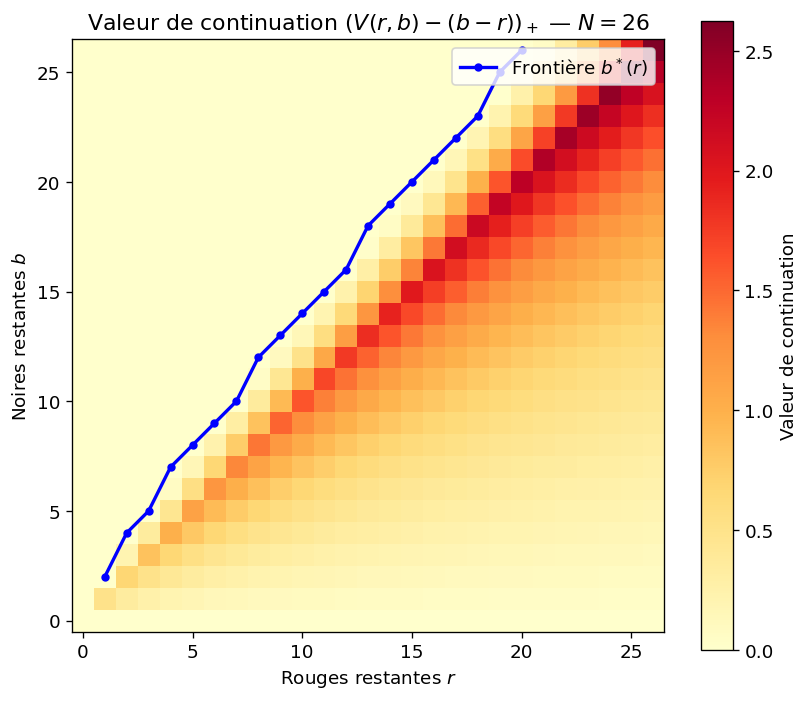

In [10]:
def frontiere(J, N):
    """Retourne les points (r, b) de la frontiere d'arret optimal."""
    br, bb = [], []
    for r in range(1, N+1):
        for b in range(1, N+1):
            p = r/(r+b)
            cont = p*J[r-1,b] + (1-p)*J[r,b-1]
            if b - r >= cont - 1e-10:
                br.append(r); bb.append(b)
                break
    return np.array(br), np.array(bb)

r_front, b_front = frontiere(J26, 26)

# Affichage : heatmap de la valeur de continuation
extra = np.array([[J26[r,b] - max(0, b-r) for b in range(27)] for r in range(27)])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(extra.T, origin='lower', cmap='YlOrRd', aspect='equal',
               extent=[-0.5, 26.5, -0.5, 26.5])
ax.plot(r_front, b_front, 'b-o', ms=4, lw=2, label='Frontière $b^*(r)$')
ax.set_xlabel('Rouges restantes $r$')
ax.set_ylabel('Noires restantes $b$')
ax.set_title(f'Valeur de continuation $(V(r,b)-(b-r))_+$ — $N=26$')
ax.legend(loc='upper right')
plt.colorbar(im, ax=ax, label='Valeur de continuation')
plt.tight_layout()
plt.savefig('fig1_valeur.pdf', bbox_inches='tight')
plt.show()


## Partie II — Analyse asymptotique

### Convergence de $J(N,N)/\sqrt{N}$

On observe numériquement $J(N,N) \sim C^*\sqrt{N}$ avec $C^* \approx 0.5220$.


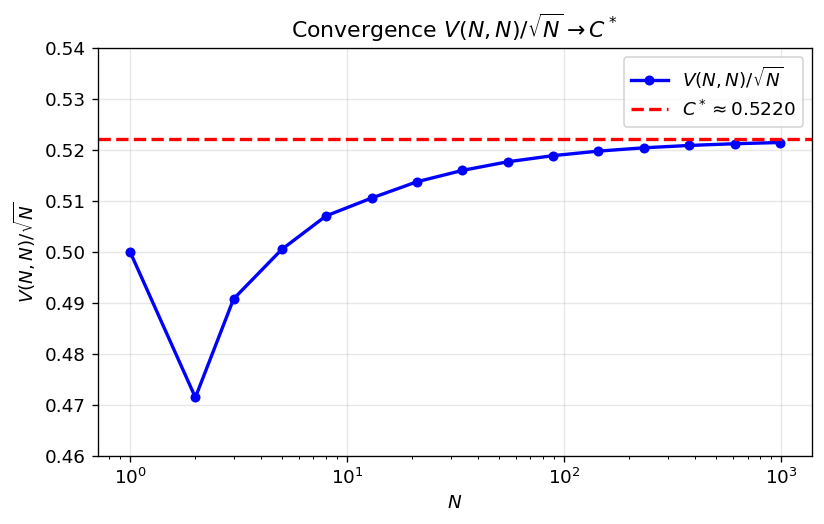

In [11]:
N_vals  = [1,2,3,5,8,13,21,34,55,89,144,233,377,610,987]
ratios  = [compute_J(Nv)[Nv,Nv]/np.sqrt(Nv) for Nv in N_vals]
C_star  = 0.52204  # extrapolation de Richardson

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogx(N_vals, ratios, 'bo-', ms=5, lw=2, label=r'$V(N,N)/\sqrt{N}$')
ax.axhline(C_star, color='r', ls='--', lw=2, label=r'$C^* \approx 0.5220$')
ax.set_xlabel('$N$')
ax.set_ylabel(r'$V(N,N)/\sqrt{N}$')
ax.set_title(r'Convergence $V(N,N)/\sqrt{N} \to C^*$')
ax.legend(); ax.set_ylim([0.46, 0.54]); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig2_convergence.pdf', bbox_inches='tight')
plt.show()


### Preuve analytique de $\mathrm{Var}(S_k)$

On note $(X_i)_{1\le i\le 2N}$ les tirages successifs, $X_i\in\{+1,-1\}$ sans remise,
et $S_k = \sum_{i=1}^k X_i$.

**Étape 1 — Moments du premier ordre** (échangeabilité).
La loi de $(X_1,\ldots,X_{2N})$ est invariante par permutation (tirage équiprobable sans remise).
Donc pour tout $i$ :
$$\mathbb{E}[X_i] = (+1)\cdot\frac{N}{2N} + (-1)\cdot\frac{N}{2N} = 0.$$

**Étape 2 — Covariance** (pour $i\neq j$).
$$\mathbb{E}[X_i X_j] = \Pr(\text{même signe}) - \Pr(\text{signes opposés}).$$
$$\Pr(\text{deux rouges}) = \frac{N(N-1)}{2N(2N-1)}, \quad
  \Pr(\text{deux noires}) = \frac{N(N-1)}{2N(2N-1)},$$
$$\Pr(\text{même signe}) = \frac{2N(N-1)}{2N(2N-1)} = \frac{N-1}{2N-1}, \quad
  \Pr(\text{signes opposés}) = 1 - \frac{N-1}{2N-1} = \frac{N}{2N-1}.$$
Donc $\mathbb{E}[X_iX_j] = \frac{N-1}{2N-1} - \frac{N}{2N-1} = -\frac{1}{2N-1},$
et $\mathrm{Cov}(X_i,X_j) = -\dfrac{1}{2N-1}$.

**Étape 3 — Variance de $S_k$**.
$$\mathrm{Var}(S_k) = \sum_{i=1}^k \mathrm{Var}(X_i) + \sum_{\substack{i,j=1\\i\neq j}}^k \mathrm{Cov}(X_i,X_j)
= k - \frac{k(k-1)}{2N-1} = \frac{k(2N-k)}{2N-1}.$$


In [6]:
# Verification numerique de Var(S_k) = k(2N-k)/(2N-1)
N_test, k_test = 20, 8
theory = k_test*(2*N_test - k_test)/(2*N_test - 1)

rng2 = np.random.default_rng(0)
n_sim = 200_000
scores_k = np.array([
    np.random.choice(np.array([1]*N_test + [-1]*N_test), size=2*N_test, replace=False)[:k_test].sum()
    for _ in range(n_sim)
])
print(f"N={N_test}, k={k_test}")
print(f"  Var theorique  : {theory:.6f}")
print(f"  Var simulee    : {np.var(scores_k):.6f}")
print(f"  E[S_k] simule  : {np.mean(scores_k):.6f}  (theorique : 0)")


N=20, k=8
  Var theorique  : 6.564103
  Var simulee    : 6.574338
  E[S_k] simule  : 0.001570  (theorique : 0)


### Covariance $\mathrm{Cov}(S_k, S_l)$ pour $k \leq l$

$$\mathrm{Cov}(S_k, S_l)
= \sum_{i=1}^k\sum_{j=1}^l \mathrm{Cov}(X_i,X_j)
= k - \frac{k(l-1)}{2N-1} = \frac{k(2N-l)}{2N-1},$$

car il y a $k$ termes diagonaux ($i=j\le k$) valant $1$ chacun,
et $k(l-1)$ termes hors-diagonaux ($i\le k$, $j\le l$, $i\neq j$) valant $-\frac{1}{2N-1}$.

**Normalisation :** posons $X^N_t = S_{\lfloor 2Nt\rfloor}/\sqrt{N}$, $t\in[0,1]$. Pour $s\le t$ :

$$\mathrm{Cov}(X^N_s, X^N_t)
= \frac{1}{N}\cdot\frac{\lfloor 2Ns\rfloor(2N - \lfloor 2Nt\rfloor)}{2N-1}
\xrightarrow{N\to\infty} \frac{2Ns\cdot 2N(1-t)}{N\cdot 2N} = 2s(1-t).$$

Or $\mathrm{Cov}(\sqrt{2}\,\beta_s, \sqrt{2}\,\beta_t) = 2\,\mathrm{Cov}(\beta_s,\beta_t) = 2s(1-t)$
pour le pont brownien standard $(\beta_t)$ (covariance $s(1-t)$).

**Conclusion :** $X^N \xrightarrow{(d)} \sqrt{2}\,\beta$ dans $C([0,1])$ (théorème de Donsker conditionné).


In [7]:
# Verification numerique de Cov(S_k, S_l) = k(2N-l)/(2N-1)
N_test, k_test, l_test = 15, 5, 10
theory_cov = k_test*(2*N_test - l_test)/(2*N_test - 1)

n_sim = 100_000
sk_arr, sl_arr = [], []
for _ in range(n_sim):
    deck = np.array([1]*N_test+[-1]*N_test)
    np.random.shuffle(deck)
    sk_arr.append(deck[:k_test].sum())
    sl_arr.append(deck[:l_test].sum())
cov_sim = np.cov(sk_arr, sl_arr)[0,1]

print(f"Cov(S_{k_test}, S_{l_test}) theorique : {theory_cov:.6f}")
print(f"Cov(S_{k_test}, S_{l_test}) simulee   : {cov_sim:.6f}")

# Verification de la covariance normalisee
s, t = k_test/(2*N_test), l_test/(2*N_test)
print(f"\nCovariance normalisee limite 2s(1-t) = {2*s*(1-t):.6f}")
print(f"Covariance normalisee discrete       = {theory_cov/N_test:.6f}")


Cov(S_5, S_10) theorique : 3.448276
Cov(S_5, S_10) simulee   : 3.424691

Covariance normalisee limite 2s(1-t) = 0.222222
Covariance normalisee discrete       = 0.229885


### Convergence en loi — comparaison de trajectoires

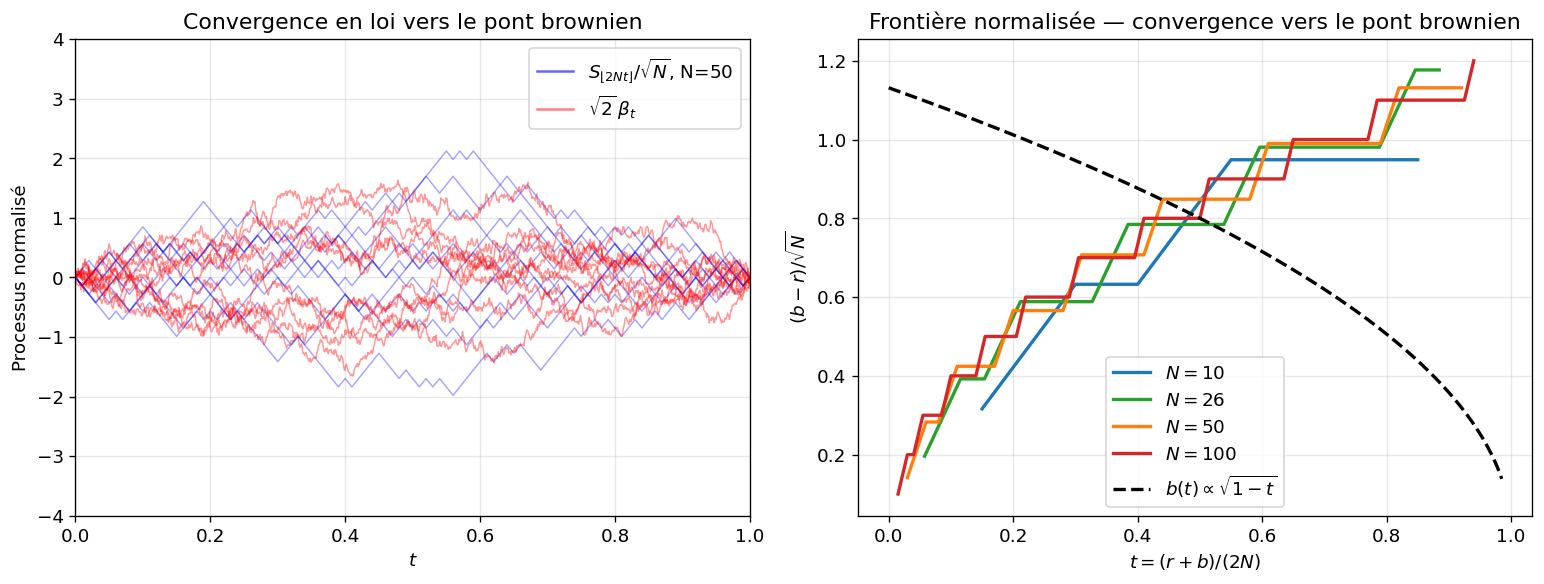

In [8]:
np.random.seed(42)
N_demo = 50

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panneau gauche : trajectoires
ax = axes[0]
t_disc = np.linspace(0, 1, 2*N_demo+1)
for _ in range(10):
    deck = np.array([1]*N_demo + [-1]*N_demo, dtype=float)
    np.random.shuffle(deck)
    path = np.concatenate([[0], np.cumsum(deck)]) / np.sqrt(N_demo)
    ax.plot(t_disc, path, 'b-', alpha=0.35, lw=0.9)

steps = 1000; dt = 1/steps; t_bb = np.linspace(0, 1, steps+1)
for _ in range(10):
    dW   = np.sqrt(dt)*np.random.randn(steps)
    W    = np.concatenate([[0], np.cumsum(dW)])
    beta = W - t_bb*W[-1]
    ax.plot(t_bb, np.sqrt(2)*beta, 'r-', alpha=0.4, lw=0.9)

ax.plot([],[],'b-',alpha=0.6,label=f'$S_{{\\lfloor 2Nt\\rfloor}}/\\sqrt{{N}}$, N={N_demo}')
ax.plot([],[],'r-',alpha=0.5,label=r'$\sqrt{2}\,\beta_t$')
ax.set_xlabel('$t$'); ax.set_ylabel('Processus normalisé')
ax.set_title('Convergence en loi vers le pont brownien')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xlim([0,1]); ax.set_ylim([-4,4])

# Panneau droit : frontiere normalisee
ax = axes[1]
colors = ['#1f77b4','#2ca02c','#ff7f0e','#d62728']
for idx, Nv in enumerate([10, 26, 50, 100]):
    Jv = compute_J(Nv)
    t_vals, x_vals = [], []
    for r in range(1, Nv+1):
        for b in range(1, Nv+1):
            p = r/(r+b)
            if b-r >= p*Jv[r-1,b]+(1-p)*Jv[r,b-1]-1e-9:
                t_vals.append((r+b)/(2*Nv))
                x_vals.append((b-r)/np.sqrt(Nv))
                break
    ax.plot(t_vals, x_vals, color=colors[idx], lw=2, label=f'$N={Nv}$')

t_th = np.linspace(0.0, 0.985, 300)
ax.plot(t_th, 0.80*np.sqrt(2*(1-t_th)), 'k--', lw=2, label=r'$b(t)\propto\sqrt{1-t}$')
ax.set_xlabel(r'$t = (r+b)/(2N)$')
ax.set_ylabel(r'$(b-r)/\sqrt{N}$')
ax.set_title('Frontière normalisée — convergence vers le pont brownien')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig4_simulations.pdf', bbox_inches='tight')
plt.show()


### Extrapolation de la constante $C^*$

On suppose un développement $J(N,N)/\sqrt{N} = C^* + a/N^\alpha + o(N^{-\alpha})$.

**Extrapolation de Richardson** avec les paires $(N, 2N)$ :
$$C^* \approx \frac{2^\alpha\,f(2N) - f(N)}{2^\alpha - 1}, \quad \alpha = \frac{\log(|f(N)-f(N/2)|/|f(2N)-f(N)|)}{\log 2}.$$


In [9]:
ns_rich = [500, 1000, 2000, 4000]
fs = [compute_J(n)[n,n]/np.sqrt(n) for n in ns_rich]

alpha_hat = np.log((fs[1]-fs[0])/(fs[2]-fs[1]))/np.log(2)
C_richardson = (2**alpha_hat*fs[2] - fs[1])/(2**alpha_hat - 1)

print(f"alpha estime : {alpha_hat:.4f}")
print(f"C* (Richardson) : {C_richardson:.8f}")
print(f"sqrt(2)*v_BB    : ~ {np.sqrt(2)*0.369:.6f}  (v_BB simule ~ 0.369)")
print()
for n, f in zip(ns_rich, fs):
    print(f"  N={n:5d} : J(N,N)/sqrt(N) = {f:.10f}")


alpha estime : 0.6930
C* (Richardson) : 0.52204646
sqrt(2)*v_BB    : ~ 0.521845  (v_BB simule ~ 0.369)

  N=  500 : J(N,N)/sqrt(N) = 0.5210719406
  N= 1000 : J(N,N)/sqrt(N) = 0.5214436441
  N= 2000 : J(N,N)/sqrt(N) = 0.5216735718
  N= 4000 : J(N,N)/sqrt(N) = 0.5218151679


## Conclusion

| Quantité | Valeur |
|---|---|
| $J(26,26)$ | $\approx 2.624$ dollars |
| $C^* = \lim_N J(N,N)/\sqrt{N}$ | $\approx 0.5220$ |
| $C^* = \sqrt{2}\,v^*$ | $v^* \approx 0.369$ (valeur pont brownien) |
| Borne sup. $C^* \leq \sqrt{\pi}/2$ | $\approx 0.886$ (espérance du sup du pont brownien) |

**Règle optimale :** s'arrêter dès que $b - r \geq \dfrac{r}{r+b}\,J(r-1,b) + \dfrac{b}{r+b}\,J(r,b-1)$.

**Limite continue :** le processus normalisé $S_{\lfloor 2Nt\rfloor}/\sqrt{N} \to \sqrt{2}\,\beta_t$
(pont brownien), et la constante $C^* = \sqrt{2}\,v^*$ où $v^*$ est la valeur d'arrêt optimal
du pont brownien (Ekström & Wanntorp, 2009).
